Dataset:
 CustomerID  Annual_Income  Spending_Score
          1             15              78
          2             16              82
          3             18              70
          4             20              88
          5             22              75
          6             24              85
          7             45              45
          8             48              52
          9             50              40
         10             52              55
         11             55              48
         12             58              42
         13             80              15
         14             85              22
         15             88              10
         16             90              28
         17             95              18
         18             98              25

K   Inertia   Silhouette
1    36.000   -
2    10.080   0.617
3     1.420   0.753
4     1.076   0.624
5     0.803   0.486
6     0.597   0.336

Cluster assignments:
 CustomerI

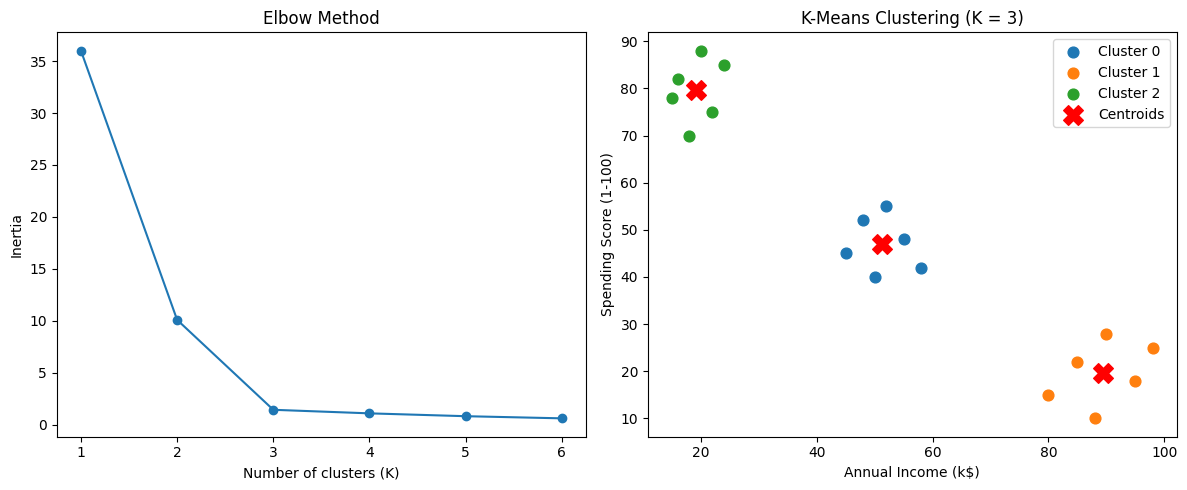

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

data = {
    'CustomerID': list(range(1, 19)),
    'Annual_Income': [15, 16, 18, 20, 22, 24, 45, 48, 50, 52, 55, 58,
                      80, 85, 88, 90, 95, 98],
    'Spending_Score': [78, 82, 70, 88, 75, 85, 45, 52, 40, 55, 48, 42,
                       15, 22, 10, 28, 18, 25]
}
df = pd.DataFrame(data)
print("Dataset:")
print(df.to_string(index=False))

X = df[['Annual_Income', 'Spending_Score']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []
print("\nK   Inertia   Silhouette")
for k in range(1, 7):
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_scaled)
    inertia.append(km.inertia_)
    if k > 1:
        sil = silhouette_score(X_scaled, km.labels_)
        print(f"{k}   {km.inertia_:7.3f}   {sil:.3f}")
    else:
        print(f"{k}   {km.inertia_:7.3f}   -")

kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print("\nCluster assignments:")
print(df.to_string(index=False))

centroids = scaler.inverse_transform(kmeans.cluster_centers_)
print("\nCluster centroids (Income, Spending):")
for i, c in enumerate(centroids):
    print(f"Cluster {i}: Income = {c[0]:.2f}, Spending = {c[1]:.2f}")

print("\nCustomers per cluster:")
print(df['Cluster'].value_counts().sort_index())
print("\nSilhouette score (K=3):",
      round(silhouette_score(X_scaled, df['Cluster']), 3))

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(range(1, 7), inertia, marker='o')
ax[0].set_xlabel("Number of clusters (K)")
ax[0].set_ylabel("Inertia")
ax[0].set_title("Elbow Method")

colors = ['tab:blue', 'tab:orange', 'tab:green']
for i in range(3):
    pts = df[df['Cluster'] == i]
    ax[1].scatter(pts['Annual_Income'], pts['Spending_Score'],
                  c=colors[i], label=f"Cluster {i}", s=60)
ax[1].scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X',
              s=200, label='Centroids')
ax[1].set_xlabel("Annual Income (k$)")
ax[1].set_ylabel("Spending Score (1-100)")
ax[1].set_title("K-Means Clustering (K = 3)")
ax[1].legend()
plt.tight_layout()
plt.show()
